# High-Level Backtesting of the ICT SMC Strategy (1H + 5m)

## Deterministic ICT Assumptions
- 1H timeframe drives BOS, FVG, breaker blocks, and liquidity pools.
- 5m timeframe drives sweep + displacement confirmation and execution timing.
- Causal safety: pivots are confirmed with right-side bars, so no lookahead/repainting logic is used.
- FVG mitigation uses the 50% fill rule (midpoint); zones stay active until full fill.

In [1]:
# imports
import time
import pandas as pd
from nautilus_trader.backtest.config import BacktestVenueConfig, BacktestDataConfig, BacktestRunConfig
from nautilus_trader.backtest.engine import BacktestResult, BacktestEngine, BacktestEngineConfig
from nautilus_trader.backtest.node import BacktestNode
from nautilus_trader.common.config import LoggingConfig
from nautilus_trader.core.datetime import dt_to_unix_nanos
from nautilus_trader.model import BarType, Bar, Venue, InstrumentId
from nautilus_trader.model.enums import OmsType
from nautilus_trader.persistence.catalog import ParquetDataCatalog
from nautilus_trader.persistence.config import DataCatalogConfig
from nautilus_trader.test_kit.providers import TestInstrumentProvider
from nautilus_trader.trading import trader
from nautilus_trader.trading.config import ImportableStrategyConfig
import sys
from pathlib import Path
from core.enums.money_management_type import MoneyManagementType

In [2]:
sys.path.append(str(Path.cwd().parent))

catalog = ParquetDataCatalog("../catalog")

start_ns = dt_to_unix_nanos(pd.Timestamp("2025-01-01"))
end_ns = dt_to_unix_nanos(pd.Timestamp("2025-10-22"))

instrument = TestInstrumentProvider.es_future(2025, 12)
instrument_id = instrument.id.value

# Configure backtesting
venue = BacktestVenueConfig(
    name="GLBX",
    oms_type=OmsType.NETTING,
    account_type="MARGIN",
    base_currency="USD",
    starting_balances=["30_000 USD"],
)

catalog_cfg = DataCatalogConfig(
    path=str(catalog.path),
    fs_protocol="file",
    name="local",
)

base_bar_type = BarType.from_str(f"{instrument_id}-1-MINUTE-LAST-EXTERNAL")
htf_bar_type = BarType.from_str(f"{instrument_id}-1-HOUR-LAST-INTERNAL@1-MINUTE-EXTERNAL")
ltf_bar_type = BarType.from_str(f"{instrument_id}-5-MINUTE-LAST-INTERNAL@1-MINUTE-EXTERNAL")

data = BacktestDataConfig(
    catalog_path=str(catalog.path),
    catalog_fs_protocol="file",
    data_cls=Bar,
    bar_types=[base_bar_type],
    instrument_id=instrument_id,
    start_time=start_ns,
    end_time=end_ns,
)

engine = BacktestEngineConfig(
    strategies=[
        ImportableStrategyConfig(
            strategy_path="strategies.ict_smc_strategy:IctSmcStrategy",
            config_path="strategies.ict_smc_strategy:IctSmcStrategyConfig",
            config={
                "instrument_id": instrument_id,
                "base_bar_type": base_bar_type,
                "htf_bar_type": htf_bar_type,
                "ltf_bar_type": ltf_bar_type,
                "is_backtest": True,

                "warmup_lookback_days": 120,

                "money_management_type": MoneyManagementType.FIXED_RISK_PERCENT,
                "fixed_lot": 1.0,
                "fixed_risk_percent": 1.0,
                "use_take_profit_order": True,

                "htf_pivot_left": 2,
                "htf_pivot_right": 2,
                "htf_bos_close_break_atr_mult": 0.0,
                "htf_atr_period": 14,
                "htf_fvg_mitigation_mode": "midpoint",
                "htf_liquidity_min_points": 2,
                "htf_liquidity_atr_tolerance_mult": 0.15,
                "htf_liquidity_swing_lookback": 25,
                "htf_breaker_source_lookback": 12,
                "htf_recent_liquidity_sweep_bars": 8,
                "htf_breaker_reclaim_valid_bars": 6,
                "htf_liquidity_sweep_buffer_atr_mult": 0.05,

                "ltf_atr_period": 14,
                "ltf_displacement_body_atr_mult": 1.2,
                "ltf_local_sweep_lookback": 8,
                "ltf_setup_expiry_bars": 3,
                "entry_buffer_atr_mult": 0.02,
                "stop_buffer_atr_mult": 0.05,
                "zone_touch_tolerance_atr_mult": 0.10,

                "min_risk_reward": 1.0,
                "fallback_risk_reward": 2.0,

                "session_timezone": "America/New_York",
                "session_start": "09:30",
                "session_end": "16:00",
                "max_trades_per_day": 2,
                "cooldown_bars": 6,
                "max_open_positions": 1,
            },
        ),
    ],
    logging=LoggingConfig(log_level="ERROR"),
    catalogs=[catalog_cfg],
)

config = BacktestRunConfig(
    engine=engine,
    venues=[venue],
    data=[data],
)

node = BacktestNode(configs=[config])

# run backtesting
elapsed_start = time.perf_counter()
results: list[BacktestResult] = node.run()
elapsed_end = time.perf_counter()

print(f"Elapsed time: {elapsed_end - elapsed_start:.6f} seconds")


Elapsed time: 94.985514 seconds


In [3]:
result = results[0]

print(f"{'='*60}")
print(f"BACKTEST RESULTS")
print(f"{'='*60}")
print(f"Trader ID:        {result.trader_id}")
print(f"Run ID:           {result.run_id}")
print(f"Backtest Period:  {pd.Timestamp(result.backtest_start, unit='ns')} → {pd.Timestamp(result.backtest_end, unit='ns')}")
print(f"Elapsed Time:     {result.elapsed_time / 1e9:.2f} seconds")
print(f"Iterations:       {result.iterations:,}")
print(f"Total Orders:     {result.total_orders}")
print(f"Total Positions:  {result.total_positions}")

print(f"\n{'='*60}")
print(f"PNL STATISTICS (USD)")
print(f"{'='*60}")
pnl = result.stats_pnls.get('USD', {})
print(f"PnL (total):      ${pnl.get('PnL (total)', 0):,.2f}")
print(f"PnL% (total):     {pnl.get('PnL% (total)', 0):.2f}%")
print(f"Expectancy:       ${pnl.get('Expectancy', 0):,.2f}")
print(f"Win Rate:         {pnl.get('Win Rate', 0)*100:.2f}%")
print(f"Max Winner:       ${pnl.get('Max Winner', 0):,.2f}")
print(f"Avg Winner:       ${pnl.get('Avg Winner', 0):,.2f}")
print(f"Min Winner:       ${pnl.get('Min Winner', 0):,.2f}")
print(f"Max Loser:        ${pnl.get('Max Loser', 0):,.2f}")
print(f"Avg Loser:        ${pnl.get('Avg Loser', 0):,.2f}")
print(f"Min Loser:        ${pnl.get('Min Loser', 0):,.2f}")

print(f"\n{'='*60}")
print(f"RETURN STATISTICS")
print(f"{'='*60}")
ret = result.stats_returns
print(f"Sharpe Ratio (252d):   {ret.get('Sharpe Ratio (252 days)', 0):.4f}")
print(f"Sortino Ratio (252d):  {ret.get('Sortino Ratio (252 days)', 0):.4f}")
print(f"Profit Factor:         {ret.get('Profit Factor', 0):.4f}")
print(f"Returns Volatility:    {ret.get('Returns Volatility (252 days)', 0):.4f}")
print(f"Risk Return Ratio:     {ret.get('Risk Return Ratio', 0):.4f}")
print(f"Avg Return:            {ret.get('Average (Return)', 0)*100:.4f}%")
print(f"Avg Win Return:        {ret.get('Average Win (Return)', 0)*100:.4f}%")
print(f"Avg Loss Return:       {ret.get('Average Loss (Return)', 0)*100:.4f}%")


BACKTEST RESULTS
Trader ID:        BACKTESTER-001
Run ID:           ff9d8ac2-0ec5-4a29-994c-f1219f6b7c18
Backtest Period:  2025-01-01 23:01:00 → 2025-10-20 00:00:00
Elapsed Time:     0.03 seconds
Iterations:       282,241
Total Orders:     93
Total Positions:  1

PNL STATISTICS (USD)
PnL (total):      $8,715.08
PnL% (total):     29.05%
Expectancy:       $281.13
Win Rate:         48.39%
Max Winner:       $3,629.00
Avg Winner:       $974.76
Min Winner:       $230.29
Max Loser:        $-419.28
Avg Loser:        $-369.15
Min Loser:        $-314.24

RETURN STATISTICS
Sharpe Ratio (252d):   4.7846
Sortino Ratio (252d):  20.6290
Profit Factor:         3.1097
Returns Volatility:    0.3194
Risk Return Ratio:     0.2865
Avg Return:            0.5673%
Avg Win Return:        1.7282%
Avg Loss Return:       -0.5210%


In [4]:
backtest_engine: BacktestEngine = node.get_engine(config.id)
positions = backtest_engine.trader.generate_positions_report()

In [5]:
len(positions)

31

In [6]:
pd.set_option("display.max_rows", 20)   # show all rows
pd.set_option("display.max_columns", None)  # show all cols

# Reduce font size for DataFrame display
from IPython.display import display, HTML
display(HTML("<style>.dataframe { font-size: 12px; }</style>"))
positions

,trader_id,strategy_id,instrument_id,account_id,opening_order_id,closing_order_id,entry,side,quantity,peak_qty,ts_init,ts_opened,ts_last,ts_closed,duration_ns,avg_px_open,avg_px_close,commissions,realized_return,realized_pnl,is_snapshot
position_id,,,,,,,,,,,,,,,,,,,,,
ESZ5.GLBX-IctSmcStrategy-000-bf602645-4a83-4f03-b913-7bdb6c542012,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250116-194000-001-000-1,O-20250116-194000-001-000-3,BUY,FLAT,0,9,1737056400000000000,2025-01-16 19:40:00+00:00,1737131220000000000,2025-01-17 16:27:00+00:00,74820000000000,5987.25,6048.42,[0.00 USD],0.01022,550.53 USD,True
ESZ5.GLBX-IctSmcStrategy-000-e25a4199-dab4-4cf2-8dd4-4f14bfaff622,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250124-200500-001-000-4,O-20250124-200500-001-000-6,SELL,FLAT,0,38,1737749100000000000,2025-01-24 20:05:00+00:00,1737962220000000000,2025-01-27 07:17:00+00:00,213120000000000,6131.75,6036.25,[0.00 USD],0.01557,3629.00 USD,True
ESZ5.GLBX-IctSmcStrategy-000-07897246-2132-4dae-9e79-59972efb8c46,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250128-151000-001-000-7,O-20250128-151000-001-000-9,BUY,FLAT,0,24,1738077000000000000,2025-01-28 15:10:00+00:00,1738078080000000000,2025-01-28 15:28:00+00:00,1080000000000,6050.75,6075.63,[0.00 USD],0.00411,597.12 USD,True
ESZ5.GLBX-IctSmcStrategy-000-5c754058-e01b-44a7-b0dd-39fbddbb984a,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250130-153500-001-000-10,O-20250130-153500-001-000-11,SELL,FLAT,0,15,1738251300000000000,2025-01-30 15:35:00+00:00,1738264440000000000,2025-01-30 19:14:00+00:00,13140000000000,6079.00,6102.16,[0.00 USD],-0.00381,-347.40 USD,True
ESZ5.GLBX-IctSmcStrategy-000-b86febc9-cf55-4e35-ad1e-1cc0ba66a3e1,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250130-204500-001-000-13,O-20250130-204500-001-000-14,SELL,FLAT,0,8,1738269900000000000,2025-01-30 20:45:00+00:00,1738287960000000000,2025-01-31 01:46:00+00:00,18060000000000,6072.00,6114.08,[0.00 USD],-0.00693,-336.64 USD,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ESZ5.GLBX-IctSmcStrategy-000-cb4d1d2b-5146-4e12-b569-a3ec498994bd,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250829-200500-001-000-79,O-20250829-200500-001-000-80,BUY,FLAT,0,8,1756497900000000000,2025-08-29 20:05:00+00:00,1756809060000000000,2025-09-02 10:31:00+00:00,311160000000000,6473.50,6427.20,[0.00 USD],-0.00715,-370.40 USD,True
ESZ5.GLBX-IctSmcStrategy-000-102d996b-bfd5-4189-815c-28e8377de723,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20250903-141000-001-000-82,O-20250903-141000-001-000-83,BUY,FLAT,0,41,1756908600000000000,2025-09-03 14:10:00+00:00,1756918260000000000,2025-09-03 16:51:00+00:00,9660000000000,6446.25,6436.92,[0.00 USD],-0.00145,-382.53 USD,True
ESZ5.GLBX-IctSmcStrategy-000-38585713-054b-4d9a-80d1-799f6a3f2ef9,BACKTESTER-001,IctSmcStrategy-000,ESZ5.GLBX,GLBX-001,O-20251006-142000-001-000-85,O-20251006-142000-001-000-87,BUY,FLAT,0,32,1759760400000000000,2025-10-06 14:20:00+00:00,1759842120000000000,2025-10-07 13:02:00+00:00,81720000000000,6774.75,6800.66,[0.00 USD],0.00382,829.12 USD,True


In [7]:
# Access portfolio analyzer
portfolio = backtest_engine.portfolio
fills_report = backtest_engine.trader.generate_fills_report()

# Get different categories of statistics
stats_pnls = portfolio.analyzer.get_performance_stats_pnls()
stats_returns = portfolio.analyzer.get_performance_stats_returns()
stats_general = portfolio.analyzer.get_performance_stats_general()

Max drawdown ($): -2,779.49
Max drawdown (%): -6.84%


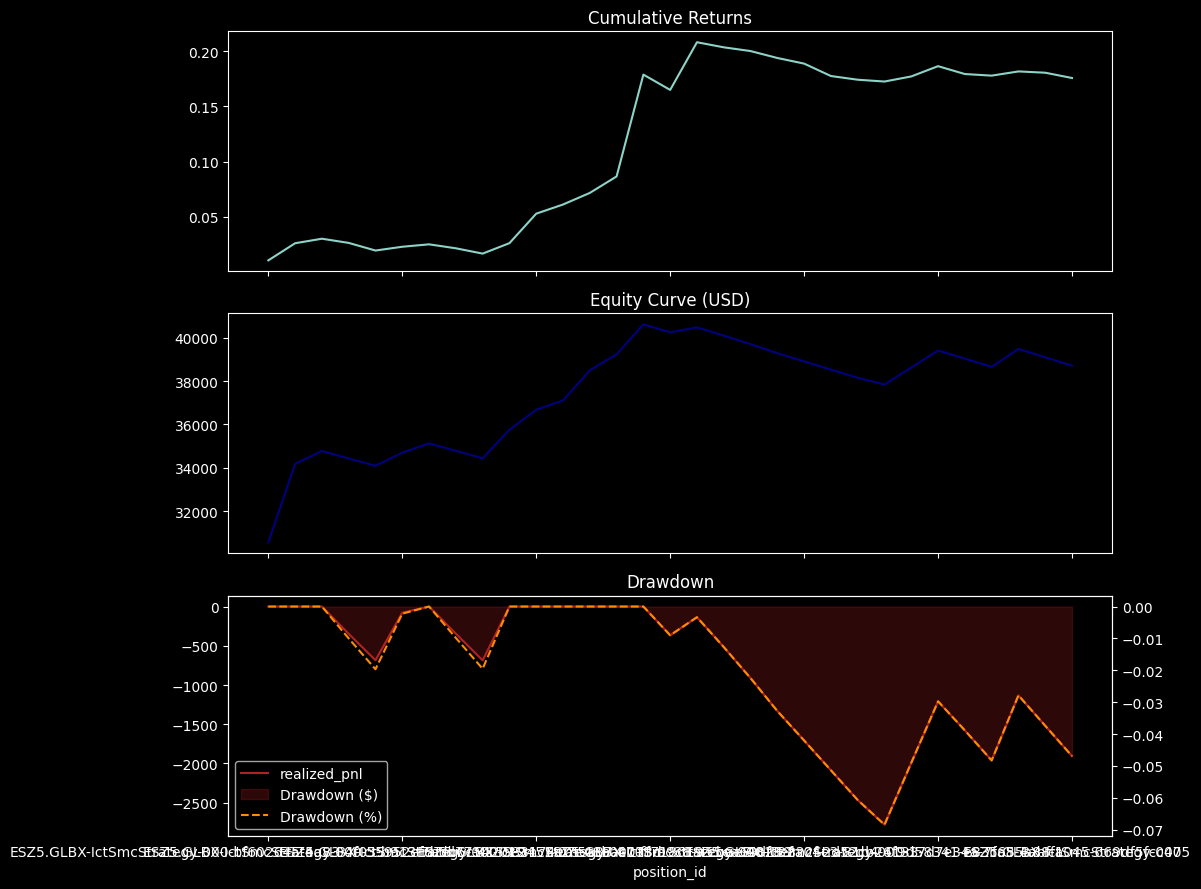

In [8]:
import matplotlib.pyplot as plt


def _money_to_float(series):
    if series.empty:
        return series
    if series.dtype != "O":
        return series
    cleaned = series.astype(str).str.replace(",", "")
    numeric = cleaned.str.split().str[0]
    return pd.to_numeric(numeric, errors="coerce")


positions_report = backtest_engine.trader.generate_positions_report()

if len(positions_report) == 0:
    print("No positions to report.")
else:
    returns_series = _money_to_float(positions_report["realized_return"])
    cumulative_returns = returns_series.cumsum()

    starting_balance = 30_000
    if "realized_pnl" in positions_report.columns:
        pnl_series = _money_to_float(positions_report["realized_pnl"])
        equity = pnl_series.cumsum() + starting_balance
    else:
        equity = cumulative_returns + starting_balance

    peak = equity.cummax()
    drawdown = equity - peak
    drawdown_pct = equity / peak - 1

    print(f"Max drawdown ($): {drawdown.min():,.2f}")
    print(f"Max drawdown (%): {drawdown_pct.min():.2%}")

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    cumulative_returns.plot(ax=axes[0], title="Cumulative Returns")
    equity.plot(ax=axes[1], color="navy", title="Equity Curve (USD)")

    drawdown.plot(ax=axes[2], color="firebrick", title="Drawdown")
    axes[2].fill_between(drawdown.index, drawdown, 0, color="firebrick", alpha=0.25, label="Drawdown ($)")

    ax_dd_pct = axes[2].twinx()
    drawdown_pct.plot(ax=ax_dd_pct, color="darkorange", linestyle="--", label="Drawdown (%)")

    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax_dd_pct.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc="lower left")

    plt.tight_layout()
    plt.show()
